# Задание 6

## Решение задачи классикации методом решающих деревьев

### *Цель работы:* научиться решать задачу классификации методами решающих деревьев и ансамблей на их основе.
**Основные задачи:**

• освоить метод Random Forest (Случайный лес) – алгоритма машинного обучения, относящегося к классу ансамблевых методов;

• оценить эффективность алгоритма на практическом примере;

• изучение методов визуализации модели и оценки ее корректности.

Проанализируем датасет **blood**.  Набор данных содержит информацию о донорах и выполненных ими трансфузиях до марта 2007 г. включительно. Целью исследования является построение прогноза сдачи донором крови в марте 2007 г. Полученный результат позволяет оценить вероятность посещения донором центра сдачи крови в дальнейшем и относится к задачам бинарной классификации. В исследовании используется база данных доноров медицинского центра города Синьчжу на Тайване. Из базы данных медицинского центра случайным образом были выбраны 748 доноров для анализа.

**Атрибуты:**

• *Recency* – количество месяцев с момента последней сдачи крови донором;

• *Frequency* – общее количество трансфузий донора;

• *Monetary* – количество сданной донором крови в куб. см.;

• *Time* – количество месяцев с момента первого донорства;

• *Class* – целевая переменная прогноза трансфузии.

# 1. Импортируйте необходимые библиотеки

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_breast_cancer
from sklearn.inspection import permutation_importance

np.random.seed(42)

# 2. Импортируйте набор данных из файла blood.сsv и поместите его в объект DataFrame

In [9]:
df = pd.read_csv("blood.csv")

# 3. Выведите данные

In [10]:
df.head()

,Recency,Frequency,Monetary,Time,Class
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


# 4. Получим информацию о датасете

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Recency    748 non-null    int64
 1   Frequency  748 non-null    int64
 2   Monetary   748 non-null    int64
 3   Time       748 non-null    int64
 4   Class      748 non-null    int64
dtypes: int64(5)
memory usage: 29.3 KB


# 5. Загрузка и первичный анализ данных

In [15]:
print("Общая размерность данных:", df.shape)
print("Названия всех столбцов:", df.columns.tolist())
print("Уникальные значения в целевой переменной:", df['Class'].unique())

print("\nПервые 5 строк данных:")
print(df.head())

Общая размерность данных: (748, 5)
Названия всех столбцов: ['Recency', 'Frequency', 'Monetary', 'Time', 'Class']
Уникальные значения в целевой переменной: [1 0]

Первые 5 строк данных:
   Recency  Frequency  Monetary  Time  Class
0        2         50     12500    98      1
1        0         13      3250    28      1
2        1         16      4000    35      1
3        2         20      5000    45      1
4        1         24      6000    77      0


# 6.  Разделяем данные на обучающую и тестовую выборки

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=0)

print(f"Обучающая выборка: {X_train.shape[0]} samples")
print(f"Тестовая выборка: {X_test.shape[0]} samples")

Обучающая выборка: 426 samples
Тестовая выборка: 143 samples


# 7. Создание и обучение модели Random Forest

In [18]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

print("Модель обучена!")

Модель обучена!


# 8. Прогнозирование и оценка модели

In [19]:
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели на тестовой выборке: {accuracy: 4f}")

Точность модели на тестовой выборке:  0.972028


In [23]:
target_names = [str(c) for c in sorted(y_test.unique())]

print("\n" + "="*50)
print("Отчет по классификации:")
print("="*50)
print(classification_report(
    y_test,
    y_pred,
    target_names=target_names
))


Отчет по классификации:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        53
           1       0.99      0.97      0.98        90

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143



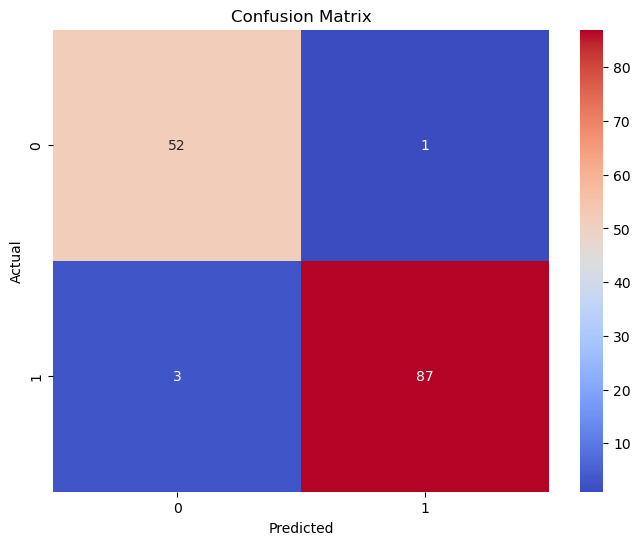

In [24]:
target_names = [str(c) for c in sorted(y_test.unique())]
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 9. Анализ важности признаков

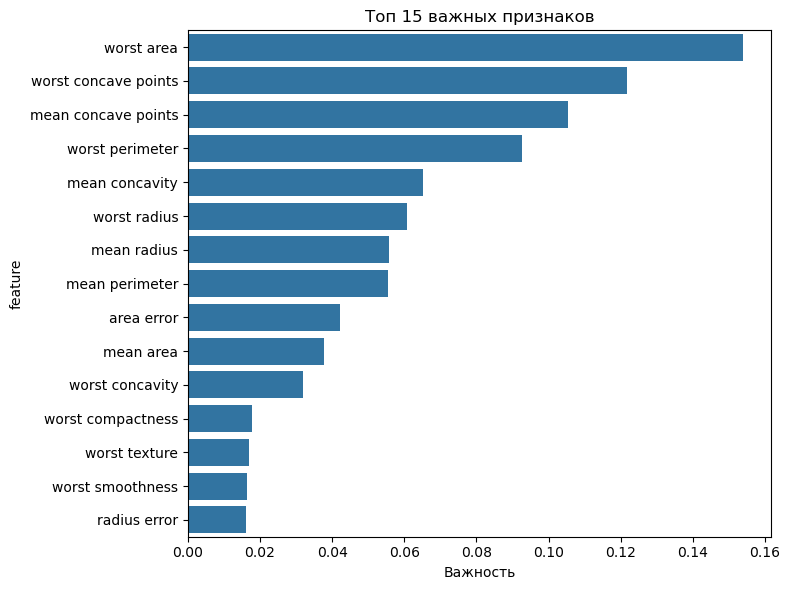

In [25]:
feature_importances = rf_model.feature_importances_
features_df = pd.DataFrame({'feature' : X.columns, 'importance' : feature_importances})
features_df = features_df.sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='importance', y='feature', data=features_df.head(15))
plt.title('Топ 15 важных признаков')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

In [26]:
print("Топ 10 самых важных признаков")
print(features_df.head(10))

Топ 10 самых важных признаков
                 feature  importance
23            worst area    0.154012
27  worst concave points    0.121658
7    mean concave points    0.105404
22       worst perimeter    0.092710
6         mean concavity    0.065273
20          worst radius    0.060749
0            mean radius    0.055807
2         mean perimeter    0.055577
13            area error    0.042099
3              mean area    0.037738


# 10. Подбор гиперпараметров

In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth' : [None, 10, 20],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [42]:
print("Лучшие параметры: ", grid_search.best_params_)
print("Лучшая точность при кросс-валидации: {:.4f}".format(grid_search.best_score_))

Лучшие параметры:  {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Лучшая точность при кросс-валидации: 0.9531


ДОПИСАТЬ ПОСЛЕДНЮЮ СТРОЧКУ!!!!